# Lab 8: Define and Solve an ML Problem of Your Choosing

In [80]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

In this lab assignment, you will follow the machine learning life cycle and implement a model to solve a machine learning problem of your choosing. You will select a data set and choose a predictive problem that the data set supports.  You will then inspect the data with your problem in mind and begin to formulate a  project plan. You will then implement the machine learning project plan. 

You will complete the following tasks:

1. Build Your DataFrame
2. Define Your ML Problem
3. Perform exploratory data analysis to understand your data.
4. Define Your Project Plan
5. Implement Your Project Plan:
    * Prepare your data for your model.
    * Fit your model to the training data and evaluate your model.
    * Improve your model's performance.

## Part 1: Build Your DataFrame

You will have the option to choose one of four data sets that you have worked with in this program:

* The "census" data set that contains Census information from 1994: `censusData.csv`
* Airbnb NYC "listings" data set: `airbnbListingsData.csv`
* World Happiness Report (WHR) data set: `WHR2018Chapter2OnlineData.csv`
* Book Review data set: `bookReviewsData.csv`

Note that these are variations of the data sets that you have worked with in this program. For example, some do not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for each of the four data sets available to you.

<b>Task:</b> In the code cell below, use the same method you have been using to load the data using `pd.read_csv()` and save it to DataFrame `df`. 

You can load each file as a new DataFrame to inspect the data before choosing your data set.

In [81]:
# File names of the four data sets
adultDataSet_filename = os.path.join(os.getcwd(), "data", "censusData.csv")
airbnbDataSet_filename = os.path.join(os.getcwd(), "data", "airbnbListingsData.csv")
WHRDataSet_filename = os.path.join(os.getcwd(), "data", "WHR2018Chapter2OnlineData.csv")
bookReviewDataSet_filename = os.path.join(os.getcwd(), "data", "bookReviewsData.csv")


df = pd.read_csv(airbnbDataSet_filename)

df.head()

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,4.79,4.86,4.41,False,3,3,0,0,0.33,9
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,4.80,4.71,4.64,False,1,1,0,0,4.86,6
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,5.00,4.50,5.00,False,1,1,0,0,0.02,3
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,4.42,4.87,4.36,False,1,0,1,0,3.68,4
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,4.95,4.94,4.92,False,1,0,1,0,0.87,7


In [82]:
# Inspecting the columns to get a sense of data!
df.columns

Index(['name', 'description', 'neighborhood_overview', 'host_name',
       'host_location', 'host_about', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_listings_count',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood_group_cleansed', 'room_type',
       'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'review_scores_rating', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value',

In [83]:
# My label -- looking at its values!
df['room_type'].unique()

array(['Entire home/apt', 'Private room', 'Hotel room', 'Shared room'],
      dtype=object)

## Part 2: Define Your ML Problem

Next you will formulate your ML Problem. In the markdown cell below, answer the following questions:

1. List the data set you have chosen.
2. What will you be predicting? What is the label?
3. Is this a supervised or unsupervised learning problem? Is this a clustering, classification or regression problem? Is it a binary classificaiton or multi-class classifiction problem?
4. What are your features? (note: this list may change after your explore your data)
5. Explain why this is an important problem. In other words, how would a company create value with a model that predicts this label?

Throughout this project I will be working with the Airbnb NYC "listings" data set (airbnbListingsData.csv). 

I will be predicting the room type of a particular listing. That is, the label will be the 'room_type' column which includes values like 'Entire home/apt', 'Private room', 'Hotel room', and 'Shared room'. 

Predicting the room type of an airbnb listing is an supervised learning problem. More specifically, it is a multi-class classification problem as there are multiple room types hence multiple classification categories. 

Some tentative features include 'description', 'neighborhood_overview', 'accomodates', 'bathrooms', 'bedrooms', 'price', 'number_of_reviews', 'review_scores_rating', 'host_response_rate', and 'availability_365'. 

Predicting the room type from listing information is good in the sense it can help the platform ensure data quality and consistency. That is, if a listings descriptions and features do not match the predicted room type, the platform can flag this listing for further review. Additionally, this model can be useful in personalized airbnb recommendations and can help auto categorize new listings.

## Part 3: Understand Your Data

The next step is to perform exploratory data analysis. Inspect and analyze your data set with your machine learning problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * addressing missingness, such as replacing missing values with means
    * finding and replacing outliers
    * renaming features and labels
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * performing specific data cleaning and preprocessing techniques for an NLP problem
    * addressing class imbalance in your data sample to promote fair AI
    

2. What machine learning model (or models) you would like to use that is suitable for your predictive problem and data?
    * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 
 
3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics and methods that are appropriate for your model?
    

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. If you are working on a classification problem, use techniques you have learned to determine if there is class imbalance.

<b>Task</b>: Use the techniques you have learned in this course to inspect and analyze your data. You can import additional packages that you have used in this course that you will need to perform this task.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-drown menu.

##### Inspect and Analyze Data!

In [84]:
df.head()

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,4.79,4.86,4.41,False,3,3,0,0,0.33,9
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,4.80,4.71,4.64,False,1,1,0,0,4.86,6
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,5.00,4.50,5.00,False,1,1,0,0,0.02,3
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,4.42,4.87,4.36,False,1,0,1,0,3.68,4
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,4.95,4.94,4.92,False,1,0,1,0,0.87,7


In [85]:
df.columns

Index(['name', 'description', 'neighborhood_overview', 'host_name',
       'host_location', 'host_about', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_listings_count',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood_group_cleansed', 'room_type',
       'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'review_scores_rating', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value',

In [86]:
df.dtypes

name                                             object
description                                      object
neighborhood_overview                            object
host_name                                        object
host_location                                    object
host_about                                       object
host_response_rate                              float64
host_acceptance_rate                            float64
host_is_superhost                                  bool
host_listings_count                             float64
host_total_listings_count                       float64
host_has_profile_pic                               bool
host_identity_verified                             bool
neighbourhood_group_cleansed                     object
room_type                                        object
accommodates                                      int64
bathrooms                                       float64
bedrooms                                        

In [87]:
df.shape

(28022, 50)

In [88]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
host_response_rate,16179.0,9.069009e-01,2.272817e-01,0.00,0.94,1.00,1.00,1.000000e+00
host_acceptance_rate,16909.0,7.919528e-01,2.767322e-01,0.00,0.68,0.91,1.00,1.000000e+00
host_listings_count,28022.0,1.455478e+01,1.207213e+02,0.00,1.00,1.00,3.00,3.387000e+03
host_total_listings_count,28022.0,1.455478e+01,1.207213e+02,0.00,1.00,1.00,3.00,3.387000e+03
accommodates,28022.0,2.874491e+00,1.860251e+00,1.00,2.00,2.00,4.00,1.600000e+01
bathrooms,28022.0,1.142174e+00,4.211317e-01,0.00,1.00,1.00,1.00,8.000000e+00
bedrooms,25104.0,1.329708e+00,7.007262e-01,1.00,1.00,1.00,1.00,1.200000e+01
beds,26668.0,1.629556e+00,1.097104e+00,1.00,1.00,1.00,2.00,2.100000e+01
price,28022.0,1.542287e+02,1.408166e+02,29.00,70.00,115.00,180.00,1.000000e+03
minimum_nights,28022.0,1.868939e+01,2.556915e+01,1.00,2.00,30.00,30.00,1.250000e+03


In [89]:
df.isna().sum()

name                                                5
description                                       570
neighborhood_overview                            9816
host_name                                           0
host_location                                      60
host_about                                      10945
host_response_rate                              11843
host_acceptance_rate                            11113
host_is_superhost                                   0
host_listings_count                                 0
host_total_listings_count                           0
host_has_profile_pic                                0
host_identity_verified                              0
neighbourhood_group_cleansed                        0
room_type                                           0
accommodates                                        0
bathrooms                                           0
bedrooms                                         2918
beds                        

In [90]:
df.duplicated().sum()

1

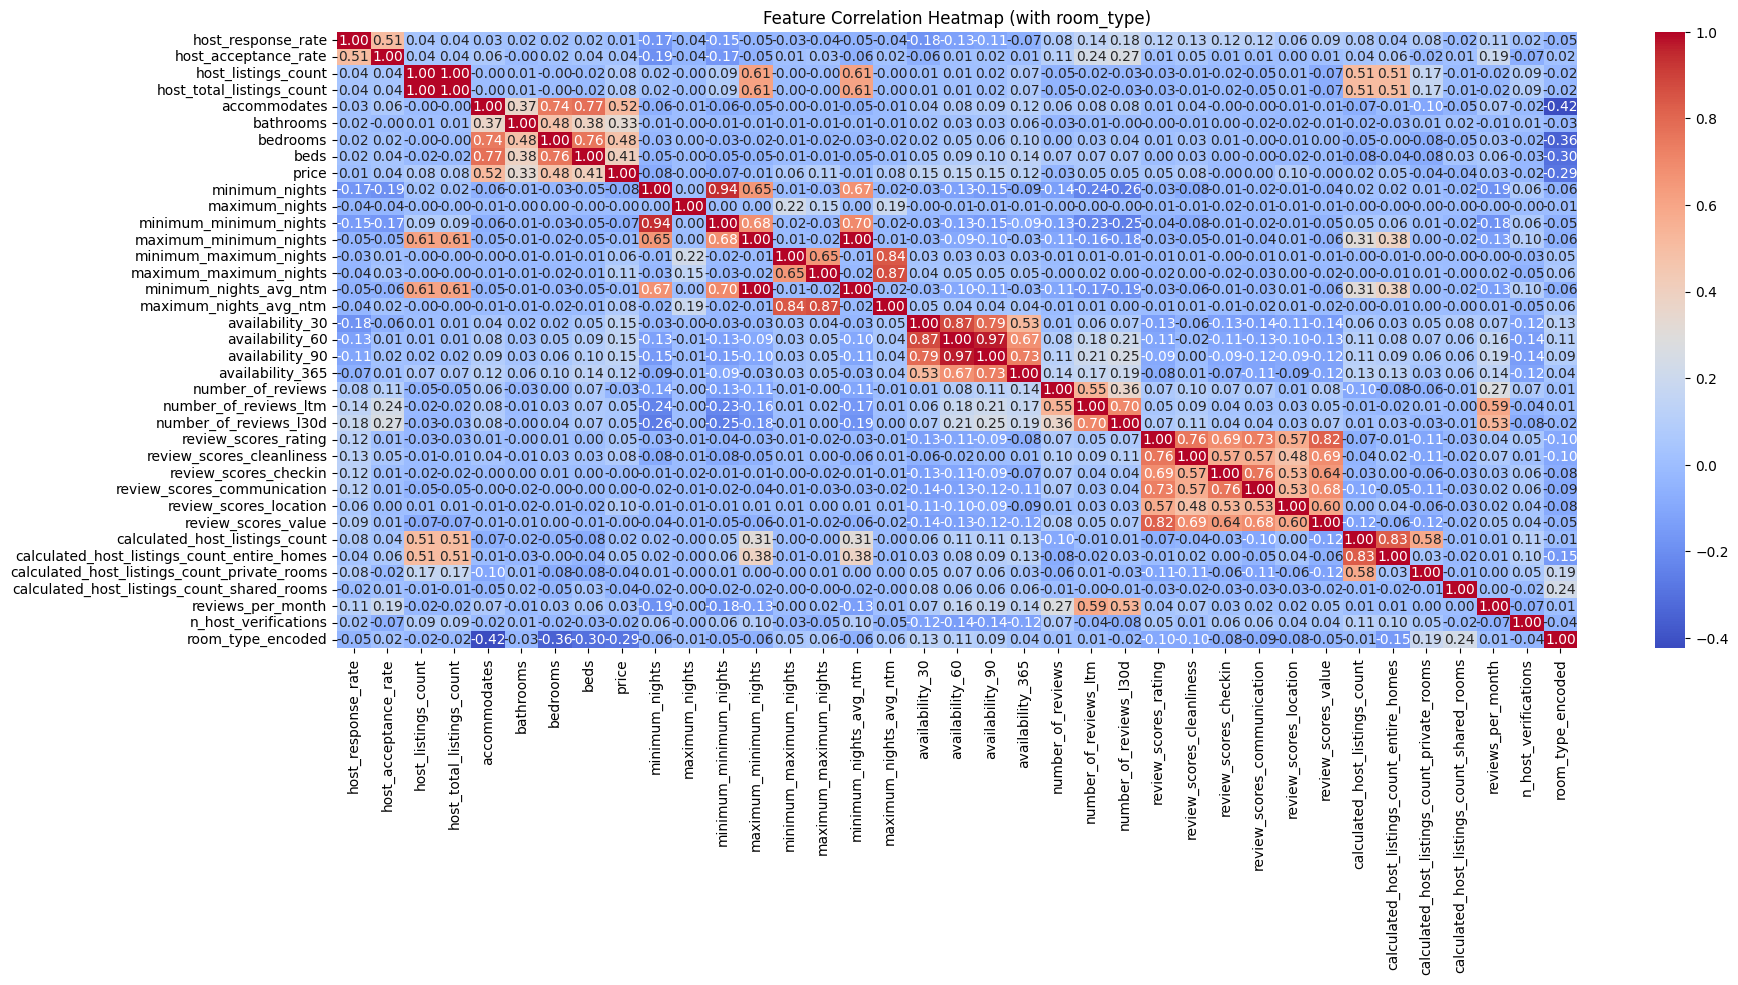

In [91]:
room_type_mapping = {'Entire home/apt': 0, 'Private room': 1, 'Shared room': 2, 'Hotel room': 3}
df['room_type_encoded'] = df['room_type'].map(room_type_mapping)

corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(20, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap (with room_type)")
plt.show()

In [92]:
# See if there is class imbalance!
df['room_type'].value_counts(normalize=True) * 100

Entire home/apt    55.684819
Private room       42.470202
Shared room         1.356077
Hotel room          0.488902
Name: room_type, dtype: float64

In [93]:
df.rename(columns={'host_is_superhost_True': 'host_is_superhost'}, inplace=True)

##### Analysis

Data preparation techniques I would like to use include addressing missingness, replacing outliers, performing feature engineering such as one hot encoding on categorical features, selecting appropriate features, removing irrelevant features, and addressing class imbalance! I am addressing missingness because there are columns with missing values. I am addressing outliers due to the fact these can skew the data severely. I am performing feature engineering, specifically one hot encoding as there are categorical feature. Lastly I am addressing class imbalance as there are much more entire home/apt in comparison to hotel room. Class imbalanced will be taken care of using class weights in my model (class_weight='balanced') so that the model focuses on underrepresented classes during training. 

The machine learning model that is well suited for predicting the room type of an airbnb listing is **random forest classifier**. Random forest classifier is suitable for my predictive problem and data as it is able to handle various data types such as numerical data and one hot encoded data. Additionally this model does not require feature scaling and can handle class imbalance as mentioned immediately above. The data preparations done are mention in the paragraph above. In short, some include one hot encoding categorical features/columns. In later steps, I will split the data into testing and training data sets and handle class imbalance. 

To evaluate and improve my models performance I will be using metrics that are suited for a multi class classification problem which includes accuracy, precision, recall, F1-Score and a confusion matrix. Additionally, I will validate my model using cross validation with folds. If the model demonstrates poor performance I can improve my model by tuning the hyperparameters (in my case adjusting the number of trees or the depth of the trees)!


## Part 4: Define Your Project Plan

Now that you understand your data, in the markdown cell below, define your plan to implement the remaining phases of the machine learning life cycle (data preparation, modeling, evaluation) to solve your ML problem. Answer the following questions:

* Do you have a new feature list? If so, what are the features that you chose to keep and remove after inspecting the data? 
* Explain different data preparation techniques that you will use to prepare your data for modeling.
* What is your model (or models)?
* Describe your plan to train your model, analyze its performance and then improve the model. That is, describe your model building, validation and selection plan to produce a model that generalizes well to new data. 

##### New Feature List

I selected the following features to predict the label `room_type` of an airbnb listing:

- `host_response_rate`
- `host_acceptance_rate`
- `accommodates`
- `bathrooms`
- `bedrooms`
- `beds`
- `price`
- `minimum_nights`
- `maximum_nights`
- `availability_365`
- `number_of_reviews`
- `review_scores_rating`
- `reviews_per_month`
- `neighbourhood_group_cleansed_Bronx`
- `neighbourhood_group_cleansed_Brooklyn`
- `neighbourhood_group_cleansed_Manhattan`
- `neighbourhood_group_cleansed_Queens`
- `neighbourhood_group_cleansed_Staten Island`
- `host_is_superhost`

I removed irrelevant features ('name', 'description', 'neighborhood_overview', 'host_name', 'host_location', 'host_about', 'host_listings_count', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'amenities', 'availability_30', 'availability_60', 'availability_90', 'number_of_reviews_ltm', 'number_of_reviews_l30d','calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'n_host_verifications', 'instant_bookable', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value') either due to the fact they were redundant, caused data leakage or held minimal predictive power. That is so the model will be trained on meaningful data that has a relationship with the room type!

##### Data Preparation Techniques

To prepare the data for modeling, I listed some techniques below. These are techniques that I will follow closely later!

- Addressing missingness: Check each column for missing values. If there were missing values, replace the missing values with the mean!
- Removing irrelevant features: This is in more detail above. In short, text based or redundant columns that have minimal predicting power was dropped.
- Outlier handling: Apply winsorization. In short, clip extreme values at the 1st and 99th percentiles.
- One hot encoding: Change the categorical values to numerical values for columns such as `neighborhood_group_cleansed` and `host_is_superhost`.
- Class imabalance: Address class imbalance using `class_weight='balanced'` in the model to ensure minority classes are represented alongside the majority!

##### Model

The model I will be using to predict the `room_type` is **Random Forest Classifier**. I will be using this model as it can handle a multitude of data types such as the numeric and categorical data seen in the data set. Additionally it can handle non linear data, does not need feature scaling and can easily handle class imbalance. These are some great reasons to use the random forest classifier model!! 

##### The Plan!

The plan to train my model, analyze its performance, and then improve the model is detailed below:

- First I will split the dataset into training set and testing set (that is, after the data preparation is completed). This step allows me to train my data using the training set and then test the performance of the model against the testing set.
- Next, the model has to be trained. This is done by creating the model and then fitting the random forest model on the training set with consideration for class imbalance (so that minority classes have a greater weight).
- After the model is trained, model validation is then required. This is where k fold cross validation will be used to assess generalization performance and ensure that overfitting does not occur. This allows us to see the range of which metrics such as accuracy, precision, recall and F1 lie.
- More simply, evaluation metrics such as accuracy, precision, recall, F1-score and a confusion matrix will be used to understand the models performance.
- With all these validation and evaluation methods, the model should be tuned for better performance. This can be done through tuning the hyperparameters such as the depth of the tree, estimators, etc using GridSearchCV. After using a variety of hyperparameter values, I will keep the values that result in the best performance! I will also use feature selection to see if selecting k best features will result in better performance. These are just few out of the many ways to improve a model. In the future, I hope to perform other model improvement methods but these are just the few that I will be focusing on in this project.

## Part 5: Implement Your Project Plan

<b>Task:</b> In the code cell below, import additional packages that you have used in this course that you will need to implement your project plan.

In [94]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

<b>Task:</b> Use the rest of this notebook to carry out your project plan. 

You will:

1. Prepare your data for your model.
2. Fit your model to the training data and evaluate your model.
3. Improve your model's performance by performing model selection and/or feature selection techniques to find best model for your problem.

Add code cells below and populate the notebook with commentary, code, analyses, results, and figures as you see fit. 

### Prepare Data for Modeling

##### Removing Irrelevant Features!


To prepare my data for modeling, I removed certain columns/features from the dataset to simplify the model to avoid noise, redundancy and prevent data leakage.

- Unique identifiers and free text features/columns were removed. Such includes 'name', 'description', 'neighborhood_overview', 'host_name', 'host_location', 'host_about'. These are unique and/or unstructured text fields that are not generalizable and require natural language processing in order for the values to be useful.
- Host information were removed. Such includes 'host_listings_count', 'host_total_listing_count', and 'calculated_host_listings_count'. These describes the host rather than the listing giving little predictive power for room type.
- Availability redundancies were removed. Such includes 'availability_30', 'availability_60', 'availability_90', and 'has_availability'. That is because the feature 'availability_365' captures availability already.
- Minimum/Maximum night redundancies were removed. Such includes 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', and 'maximum_nights_avg_ntm'. The features 'minimum_nights' and 'maximum_nights' capture this already in a simplified manner.
- Review scores were removed as it can cause potential data leakage as reviews occur after the fact. Such include 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', and 'review_scores_value'.
- Features with little predictive power were also removed. Such includes 'ammenities', 'n_host_verifications', and 'instant_bookable'. Ammenities is a long list that will require more complex processing. N host verifications count its verifications which is not useful when predicting the room type and instant bookable does not correlate much with room type.

This is a general list and reasoning to the features that were removed in the code below!

In [95]:
print(df.columns)
irrelevant_columns = {'name', 'description', 'neighborhood_overview', 'host_name', 'host_location', 'host_about', 'host_listings_count', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'amenities', 'availability_30', 'availability_60', 'availability_90', 'number_of_reviews_ltm', 'number_of_reviews_l30d','calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'n_host_verifications', 'instant_bookable', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'room_type_encoded'}
df = df.drop(columns=irrelevant_columns, errors='ignore')
df.columns

Index(['name', 'description', 'neighborhood_overview', 'host_name',
       'host_location', 'host_about', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_listings_count',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood_group_cleansed', 'room_type',
       'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'review_scores_rating', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value',

Index(['host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'neighbourhood_group_cleansed', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights',
       'maximum_nights', 'availability_365', 'number_of_reviews',
       'review_scores_rating', 'reviews_per_month'],
      dtype='object')

In [96]:
df.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_group_cleansed,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,reviews_per_month
0,0.80,0.17,True,Manhattan,Entire home/apt,1,1.0,NaN,1.0,150.0,30,1125,338,48,4.70,0.33
1,0.09,0.69,True,Brooklyn,Entire home/apt,3,1.0,1.0,3.0,75.0,1,730,194,409,4.45,4.86
2,1.00,0.25,True,Brooklyn,Entire home/apt,4,1.5,2.0,2.0,275.0,5,1125,123,2,5.00,0.02
3,1.00,1.00,True,Manhattan,Private room,2,1.0,1.0,1.0,68.0,2,14,192,507,4.21,3.68
4,NaN,NaN,True,Manhattan,Private room,1,1.0,1.0,1.0,75.0,2,14,0,118,4.91,0.87


##### Addressing Missingness!

I checked for missing values. If there were missing values, I replaced the missing values with the mean!

In [97]:
df.isna().sum()

host_response_rate              11843
host_acceptance_rate            11113
host_is_superhost                   0
neighbourhood_group_cleansed        0
room_type                           0
accommodates                        0
bathrooms                           0
bedrooms                         2918
beds                             1354
price                               0
minimum_nights                      0
maximum_nights                      0
availability_365                    0
number_of_reviews                   0
review_scores_rating                0
reviews_per_month                   0
dtype: int64

In [98]:
# Replace missing values w/ mean!
df['host_response_rate'].fillna(df['host_response_rate'].mean(), inplace=True)

In [99]:
# Replace missing values w/ mean!
df['host_acceptance_rate'].fillna(df['host_acceptance_rate'].mean(), inplace=True)

In [100]:
# Replace missing values w/ mean!
df['bedrooms'].fillna(df['bedrooms'].mean(), inplace=True)

In [101]:
# Replace missing values w/ mean!
df['beds'].fillna(df['beds'].mean(), inplace=True)

In [102]:
df.isna().sum()

host_response_rate              0
host_acceptance_rate            0
host_is_superhost               0
neighbourhood_group_cleansed    0
room_type                       0
accommodates                    0
bathrooms                       0
bedrooms                        0
beds                            0
price                           0
minimum_nights                  0
maximum_nights                  0
availability_365                0
number_of_reviews               0
review_scores_rating            0
reviews_per_month               0
dtype: int64

##### Data Preparation -- Finding and Replacing Outliers

I replaced all outliers using the method of Winsorization. All extreme values or outliers are capped at a specific percentile!

In [103]:
df.columns

Index(['host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'neighbourhood_group_cleansed', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights',
       'maximum_nights', 'availability_365', 'number_of_reviews',
       'review_scores_rating', 'reviews_per_month'],
      dtype='object')

In [104]:
columns_with_outliers = ['price', 'minimum_nights', 'maximum_nights', 'availability_365', 'reviews_per_month', 'number_of_reviews', 'bedrooms', 'beds', 'accommodates', 'bathrooms', 'host_response_rate', 'host_acceptance_rate', 'review_scores_rating']

for column in columns_with_outliers:
    df[column] = df[column].clip(lower=df[column].quantile(0.01), upper=df[column].quantile(0.99))

##### Data Preparation -- One Hot Encoding

I changed the categorical values to numerical values for columns such as 'neighborhood_group_cleansed' and 'host_is_superhost'.

In [105]:
df = pd.get_dummies(df, columns=['neighbourhood_group_cleansed', 'host_is_superhost'], drop_first=False)

In [106]:
df.head()

,host_response_rate,host_acceptance_rate,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,reviews_per_month,neighbourhood_group_cleansed_Bronx,neighbourhood_group_cleansed_Brooklyn,neighbourhood_group_cleansed_Manhattan,neighbourhood_group_cleansed_Queens,neighbourhood_group_cleansed_Staten Island,host_is_superhost_True
0,0.800000,0.170000,Entire home/apt,1.0,1.0,1.329708,1.0,150.0,30.0,1125.0,338,48.00,4.70,0.33,0,0,1,0,0,1
1,0.090000,0.690000,Entire home/apt,3.0,1.0,1.000000,3.0,75.0,1.0,730.0,194,268.79,4.45,4.86,0,1,0,0,0,1
2,1.000000,0.250000,Entire home/apt,4.0,1.5,2.000000,2.0,275.0,5.0,1125.0,123,2.00,5.00,0.02,0,1,0,0,0,1
3,1.000000,1.000000,Private room,2.0,1.0,1.000000,1.0,68.0,2.0,14.0,192,268.79,4.21,3.68,0,0,1,0,0,1
4,0.906901,0.791953,Private room,1.0,1.0,1.000000,1.0,75.0,2.0,14.0,0,118.00,4.91,0.87,0,0,1,0,0,1


##### Data Preparation -- Renaming Features and Labels

I kept most of the columns as is! The columns are all named in such a way that is easy to understand and all follow a consistent format!

In [107]:
df.columns

Index(['host_response_rate', 'host_acceptance_rate', 'room_type',
       'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
       'neighbourhood_group_cleansed_Bronx',
       'neighbourhood_group_cleansed_Brooklyn',
       'neighbourhood_group_cleansed_Manhattan',
       'neighbourhood_group_cleansed_Queens',
       'neighbourhood_group_cleansed_Staten Island', 'host_is_superhost_True'],
      dtype='object')

### Fit Model to Training Data and Evaluate Model

##### Create Labeled Examples from the Data Set

In [108]:
X = df.drop("room_type", axis=1)
y = df["room_type"]

##### Create Training and Test Data Sets

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

##### Initialize Model and Fit the Model

In [110]:
rf_model = RandomForestClassifier(n_estimators = 300, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

##### Make Predictions on Test Data

In [111]:
y_rf_pred = rf_model.predict(X_test)
proba_predictions = rf_model.predict_proba(X_test)

##### Confusion Matrix, Accuracy, Precision, Recall and F1 Score

In [112]:
# Confusion Matrix
confusionn_matrix = confusion_matrix(y_test, y_rf_pred)
print(confusionn_matrix)
# Accuracy
acc = accuracy_score(y_test, y_rf_pred)
print("Accuracy:", acc)
# Precision
prec = precision_score(y_test, y_rf_pred,average='macro')
print("Precision:", prec)
# Recall
rec = recall_score(y_test, y_rf_pred, average='macro')
print("Recall:", rec)
# F1 Score
F1s = f1_score(y_test, y_rf_pred, average='macro')
print("F1:", F1s)

[[2846    0  275    0]
 [   4   15    8    0]
 [ 343    3 2035    0]
 [   9    0   53   14]]
Accuracy: 0.8760035682426405
Precision: 0.895110115874612
Recall: 0.6265840509623081
F1: 0.6836162144668787


##### K Fold Cross Validation

In [113]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
cv_results = {}
for m in metrics:
    scores = cross_val_score(rf_model, X_train, y_train, scoring=m, cv=cv, n_jobs=-1)
    cv_results[m] = scores
    print(f"CV {m:>15}: {scores.mean():.4f} ± {scores.std():.4f}  |  folds: {np.round(scores, 4)}")

CV        accuracy: 0.8812 ± 0.0033  |  folds: [0.8809 0.8822 0.8773 0.8867 0.8787]
CV precision_macro: 0.8835 ± 0.0124  |  folds: [0.884  0.8734 0.8669 0.8926 0.901 ]
CV    recall_macro: 0.6130 ± 0.0242  |  folds: [0.5868 0.6234 0.6246 0.5834 0.6467]
CV        f1_macro: 0.6714 ± 0.0219  |  folds: [0.6482 0.679  0.6786 0.6463 0.7049]


### Improve Model Performance

In the following cells I will be performing feature selection using `SelectKBest`. Additionally, I will be using `GridSearchCV` to find the best hyperparameters.

In [114]:
df.shape # Checking how many features

(28022, 20)

##### Feature Selection Using SelectKBest

I utilized SelectKBest to find the best features for predicting room type. I played around with different values of k. I started with 5, then 10, 15 and lastly 20. I noticed k = 5 generally has worst performance. I assume the lack of other features reduced predictive power. I increased k slowely and noticed that accuracy is still low. That said, I kept the model proposed prior to the model performance state. So in short, I kept k = 20.

In [115]:
k = 20
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_train, y_train)
filter = selector.get_support()
top_k_features = X_train.columns[filter]

print("Best", k, "features:")
print(top_k_features)

new_X_train = X_train[top_k_features]
new_X_test  = X_test[top_k_features]

model = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)

model.fit(new_X_train, y_train)

proba_predictions = model.predict_proba(new_X_test)
y_pred_selected   = model.predict(new_X_test)

acc  = accuracy_score(y_test, y_pred_selected)
prec = precision_score(y_test, y_pred_selected, average='macro', zero_division=0)
rec  = recall_score(y_test, y_pred_selected, average='macro', zero_division=0)
f1   = f1_score(y_test, y_pred_selected, average='macro')

print(f"Accuracy (top {k}): {acc:.4f}")
print(f"Precision (macro):  {prec:.4f}")
print(f"Recall (macro):     {rec:.4f}")
print(f"F1 (macro):         {f1:.4f}")

Best 20 features:
Index(['host_response_rate', 'host_acceptance_rate', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights',
       'maximum_nights', 'availability_365', 'number_of_reviews',
       'review_scores_rating', 'reviews_per_month',
       'neighbourhood_group_cleansed_Bronx',
       'neighbourhood_group_cleansed_Brooklyn',
       'neighbourhood_group_cleansed_Manhattan',
       'neighbourhood_group_cleansed_Queens',
       'neighbourhood_group_cleansed_Staten Island', 'host_is_superhost_True'],
      dtype='object')


/home/ubuntu/.pyenv/versions/3.9.19/lib/python3.9/site-packages/sklearn/feature_selection/_univariate_selection.py:776: UserWarning: k=20 is greater than n_features=19. All the features will be returned.
  warnings.warn(
/home/ubuntu/.pyenv/versions/3.9.19/lib/python3.9/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [18] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/ubuntu/.pyenv/versions/3.9.19/lib/python3.9/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Accuracy (top 20): 0.8760
Precision (macro):  0.8951
Recall (macro):     0.6266
F1 (macro):         0.6836


##### Tuning Hyperparameters Using GridSearchCV

In [116]:
rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
param_grid = {"n_estimators": [100, 200, 300, 400], "max_depth": [None, 5, 10, 16, 32, 64], "min_samples_leaf": [1, 2, 4],}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {"accuracy": "accuracy", "precision_macro": "precision_macro", "recall_macro": "recall_macro", "f1_macro": "f1_macro"}
grid = GridSearchCV(estimator=rf, param_grid=param_grid, scoring=scoring, refit="f1_macro", cv=cv, n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)
print("\nBest parameters:")
print(grid.best_params_)
print(f"Best CV macro-F1: {grid.best_score_:.4f}")

best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)
cm   = confusion_matrix(y_test, y_pred)
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1   = f1_score(y_test, y_pred, average="macro")
print("\nConfusion Matrix")
print(cm)
print(f"\nTest Accuracy  : {acc:.4f}")
print(f"Test Precision : {prec:.4f} (macro)")
print(f"Test Recall    : {rec:.4f} (macro)")
print(f"Test F1        : {f1:.4f} (macro)")

Fitting 3 folds for each of 72 candidates, totalling 216 fits

Best parameters:
{'max_depth': 16, 'min_samples_leaf': 4, 'n_estimators': 300}
Best CV macro-F1: 0.6784

Confusion Matrix
[[2808    4  308    1]
 [   3   19    5    0]
 [ 322   14 2041    4]
 [   9    0   49   18]]

Test Accuracy  : 0.8717
Test Precision : 0.7598 (macro)
Test Recall    : 0.6744 (macro)
Test F1        : 0.6768 (macro)
[CV] END max_depth=None, min_samples_leaf=1, n_estimators=100; total time=   3.0s
[CV] END max_depth=None, min_samples_leaf=1, n_estimators=400; total time=   7.5s
[CV] END max_depth=None, min_samples_leaf=2, n_estimators=300; total time=   6.3s
[CV] END max_depth=None, min_samples_leaf=4, n_estimators=300; total time=   5.8s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=200; total time=   2.5s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=400; total time=   3.6s
[CV] END ..max_depth=5, min_samples_leaf=2, n_estimators=400; total time=   3.4s
[CV] END ..max_depth=5, min_sa

I used GridSearchCV to tune the hyperparameters of my Random Forest model, testing different values for n_estimators, max_depth, and min_samples_leaf. After optimization, I observed a slight decrease in overall accuracy compared to my original model: accuracy dropped from 0.8760 to 0.8717, and precision decreased from 0.8951 to 0.7598. On the other hand, recall improved from 0.6266 to 0.6744, while the F1-score slightly decreased from 0.6836 to 0.6768.

Based on these results, my original model performs better in terms of general accuracy and precision, making it more reliable for overall correct predictions. However, the tuned model improves recall, meaning it is better at identifying minority class instances. If the goal were to prioritize recall, model 2 would be more appropriate despite its lower precision and accuracy.

In the future, I aim to address class imbalance more effectively to improve recall without significantly sacrificing accuracy and precision. Additionally, given more time, I would like to explore tuning a wider range of hyperparameters, as running GridSearchCV with multiple combinations can be computationally time-consuming.